In [ ]:
!pip install torch torchvision datasets transformers --quiet



In [ ]:
!pip uninstall -y sympy
!pip install -q sympy==1.12

Found existing installation: sympy 1.14.0
Uninstalling sympy-1.14.0:
  Successfully uninstalled sympy-1.14.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 138.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.9.0+cu126 requires sympy>=1.13.3, but you have sympy 1.12 which is incompatible.


Libraries and Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

from datasets import load_dataset

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


PyTorch: 2.9.0+cu126
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


Helper Functions

In [ ]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

def count_nonzero_and_sparsity(model):
    """
    Counts nonzeros using module.weight and bias (after pruning masks).
    """
    nonzero = 0
    total = 0

    for module in model.modules():
        if hasattr(module, "weight") and module.weight is not None:
            w = module.weight
            total += w.numel()
            nonzero += torch.count_nonzero(w).item()
        if hasattr(module, "bias") and module.bias is not None:
            b = module.bias
            total += b.numel()
            nonzero += torch.count_nonzero(b).item()

    sparsity = 1.0 - nonzero / float(total)
    return nonzero, total, sparsity


CIfar-10 DataLoading

In [ ]:
from torchvision import models

batch_size = 64  # ResNet is heavier; 64 is safer than 128 on Colab

# ImageNet normalization (very important when using pretrained models)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

transform_train = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

transform_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

print("Train samples:", len(trainset), " Test samples:", len(testset))
print("Classes:", trainset.classes)


100%|██████████| 170M/170M [00:13<00:00, 12.6MB/s]


Train samples: 50000  Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


cifar-10 resnet-18

In [ ]:
def get_resnet18_cifar(num_classes=10):
    """
    Load ResNet-18 pretrained on ImageNet and adapt it for CIFAR-10.
    """

    try:

        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    except Exception:

        resnet = models.resnet18(pretrained=True)

    in_features = resnet.fc.in_features
    resnet.fc = nn.Linear(in_features, num_classes)

    return resnet

model = get_resnet18_cifar(num_classes=10).to(device)
print(model)
print("Total parameters:", count_params(model))


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 244MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Train and Evaluation Functions

In [ ]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def eval_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


Cifar-10 Baseline Training

In [ ]:
num_epochs = 10
optimizer = optim.Adam(model.parameters(), lr=1e-4)  # smaller LR for finetuning

best_test_acc = 0.0
history_cifar = {"train_acc": [], "test_acc": []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, trainloader, optimizer, criterion, device)
    test_loss, test_acc = eval_model(model, testloader, criterion, device)

    history_cifar["train_acc"].append(train_acc)
    history_cifar["test_acc"].append(test_acc)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), "cifar10_resnet18_baseline_best.pth")

    print(f"Epoch {epoch+1:02d} | "
          f"train_acc={train_acc:.3f} | test_acc={test_acc:.3f}")

print("Best CIFAR10 (ResNet18) test accuracy:", best_test_acc)
print("Saved best model -> cifar10_resnet18_baseline_best.pth")


Epoch 01 | train_acc=0.735 | test_acc=0.910
Epoch 02 | train_acc=0.814 | test_acc=0.919
Epoch 03 | train_acc=0.835 | test_acc=0.932
Epoch 04 | train_acc=0.848 | test_acc=0.936
Epoch 05 | train_acc=0.856 | test_acc=0.943
Epoch 06 | train_acc=0.862 | test_acc=0.941
Epoch 07 | train_acc=0.868 | test_acc=0.939
Epoch 08 | train_acc=0.873 | test_acc=0.943
Epoch 09 | train_acc=0.878 | test_acc=0.946
Epoch 10 | train_acc=0.882 | test_acc=0.943
Best CIFAR10 (ResNet18) test accuracy: 0.946
Saved best model -> cifar10_resnet18_baseline_best.pth


Accuracy Plot

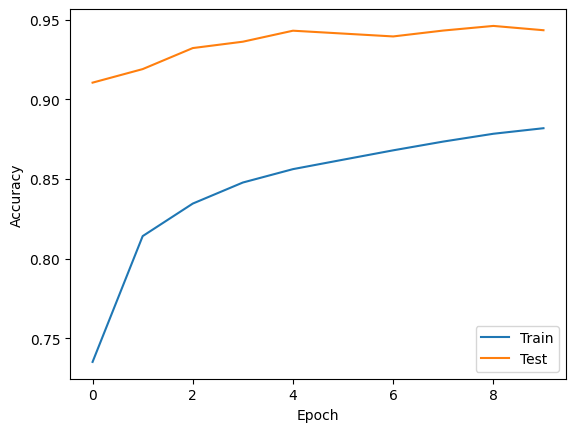

In [ ]:
plt.plot(history_cifar["train_acc"], label="Train")
plt.plot(history_cifar["test_acc"], label="Test")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


Finetuning Helper

In [ ]:
import torch.nn.utils.prune as prune

def reload_cifar_baseline():
    m = get_resnet18_cifar(num_classes=10).to(device)
    state = torch.load("cifar10_resnet18_baseline_best.pth", map_location=device)
    m.load_state_dict(state)
    return m


def remove_pruning(model):
    for module in model.modules():
        if hasattr(module, "weight_orig"):
            prune.remove(module, "weight")
    return model

def finetune(model, trainloader, testloader, epochs=5, lr=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, trainloader, optimizer, criterion, device)
        test_loss, test_acc = eval_model(model, testloader, criterion, device)
        print(f"[Finetune] Epoch {epoch+1}: train_acc={train_acc:.3f}, test_acc={test_acc:.3f}")
    return model


# **Unstructures Pruning**

In [ ]:
def apply_unstructured_pruning(model, amount):
    """
    amount = fraction to prune per layer (e.g., 0.3 for 30%)
    """
    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            prune.l1_unstructured(module, name="weight", amount=amount)
    return model


In [ ]:
import time

def measure_cifar_runtime(model, loader, num_batches=50):
    """
    Measures average latency per image (ms) and peak GPU memory (MB)
    on the first `num_batches` of `loader`.
    """
    model.eval()
    device = next(model.parameters()).device

    if device.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)

    total_images = 0
    start = time.perf_counter()

    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            if i >= num_batches:
                break
            images = images.to(device)
            _ = model(images)
            total_images += images.size(0)

    if device.type == "cuda":
        torch.cuda.synchronize(device)

    end = time.perf_counter()
    avg_ms_per_image = (end - start) / total_images * 1000.0

    if device.type == "cuda":
        peak_mem_mb = torch.cuda.max_memory_allocated(device) / (1024.0 ** 2)
    else:
        peak_mem_mb = 0.0

    return avg_ms_per_image, peak_mem_mb


Pruning For 30% 50% and 70%

In [ ]:
unstructured_results_cifar = []

for amount in [0.3, 0.5, 0.7]:
    print("\n" + "="*60)
    print(f"UNSTRUCTURED CIFAR: amount={amount*100:.0f}%")
    print("="*60)

    model_u = reload_cifar_baseline()

    nonzero_b, total_b, sparsity_b = count_nonzero_and_sparsity(model_u)
    print(f"Baseline nonzero={nonzero_b}, total={total_b}, sparsity={sparsity_b*100:.2f}%")

    apply_unstructured_pruning(model_u, amount)
    nonzero_p, total_p, sparsity_p = count_nonzero_and_sparsity(model_u)
    print(f"After pruning: nonzero={nonzero_p}, total={total_p}, sparsity={sparsity_p*100:.2f}%")

    remove_pruning(model_u)

    base_loss, base_acc = eval_model(model_u, testloader, criterion, device)
    print(f"Test accuracy BEFORE finetune: {base_acc:.3f}")

    finetune(model_u, trainloader, testloader, epochs=5, lr=1e-4)

        # Final evaluation
    final_loss, final_acc = eval_model(model_u, testloader, criterion, device)
    print(f"Test accuracy AFTER finetune: {final_acc:.3f}")

    # Runtime stats
    lat_ms, mem_mb = measure_cifar_runtime(model_u, testloader, num_batches=50)
    print(f"Runtime: {lat_ms:.3f} ms/image, {mem_mb:.1f} MB")

    unstructured_results_cifar.append({
        "amount": amount,
        "sparsity": sparsity_p,
        "acc_before": base_acc,
        "acc_after": final_acc,
        "latency_ms_per_img": lat_ms,
        "peak_mem_mb": mem_mb,
    })

print("\nUnstructured CIFAR results:", unstructured_results_cifar)



UNSTRUCTURED CIFAR: amount=30%
Baseline nonzero=11181642, total=11181642, sparsity=0.00%
After pruning: nonzero=7830033, total=11181642, sparsity=29.97%
Test accuracy BEFORE finetune: 0.943
[Finetune] Epoch 1: train_acc=0.880, test_acc=0.941
[Finetune] Epoch 2: train_acc=0.885, test_acc=0.948
[Finetune] Epoch 3: train_acc=0.887, test_acc=0.947
[Finetune] Epoch 4: train_acc=0.891, test_acc=0.942
[Finetune] Epoch 5: train_acc=0.892, test_acc=0.949
Test accuracy AFTER finetune: 0.949
Runtime: 1.016 ms/image, 707.0 MB

UNSTRUCTURED CIFAR: amount=50%
Baseline nonzero=11181642, total=11181642, sparsity=0.00%
After pruning: nonzero=5595626, total=11181642, sparsity=49.96%
Test accuracy BEFORE finetune: 0.918
[Finetune] Epoch 1: train_acc=0.873, test_acc=0.945
[Finetune] Epoch 2: train_acc=0.880, test_acc=0.944
[Finetune] Epoch 3: train_acc=0.883, test_acc=0.944
[Finetune] Epoch 4: train_acc=0.888, test_acc=0.949
[Finetune] Epoch 5: train_acc=0.891, test_acc=0.943
Test accuracy AFTER finetune

# **Structured Pruning**

In [ ]:
def apply_structured_pruning_cifar(model, amount):
    """
    amount = fraction of filters/neurons to prune per layer.
    For Conv2d: prune output channels (dim=0).
    For Linear: prune input dimension (dim=1).
    """
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            prune.ln_structured(module, name="weight", amount=amount, n=2, dim=0)
        elif isinstance(module, nn.Linear):
            prune.ln_structured(module, name="weight", amount=amount, n=2, dim=1)
    return model


Pruning For 30% 50% and 70%

In [ ]:


structured_results_cifar = []

for amount in [0.2, 0.3, 0.5]:
    print("\n" + "="*60)
    print(f"STRUCTURED CIFAR: amount={int(amount*100)}%")
    print("="*60)


    model_s = reload_cifar_baseline()


    nonzero_b, total_b, sparsity_b = count_nonzero_and_sparsity(model_s)
    print(f"Baseline nonzero={nonzero_b}, total={total_b}, sparsity={sparsity_b*100:.2f}%")


    apply_structured_pruning_cifar(model_s, amount)


    nonzero_p, total_p, sparsity_p = count_nonzero_and_sparsity(model_s)
    print(f"After pruning: nonzero={nonzero_p}, total={total_p}, sparsity={sparsity_p*100:.2f}%")

    remove_pruning(model_s)

    # Accuracy BEFORE finetune
    base_loss, base_acc = eval_model(model_s, testloader, criterion, device)
    print(f"Test accuracy BEFORE finetune: {base_acc:.3f}")

    # Fine-tune 5 epochs
    finetune(model_s, trainloader, testloader, epochs=5, lr=1e-4)

    # Accuracy AFTER finetune
    final_loss, final_acc = eval_model(model_s, testloader, criterion, device)
    print(f"Test accuracy AFTER finetune: {final_acc:.3f}")

    # Runtime and memory usage
    lat_ms, mem_mb = measure_cifar_runtime(model_s, testloader, num_batches=50)
    print(f"Runtime: {lat_ms:.3f} ms/image, Peak GPU Mem: {mem_mb:.1f} MB")

    # Store results
    structured_results_cifar.append({
        "amount": amount,
        "sparsity": sparsity_p,
        "acc_before": base_acc,
        "acc_after": final_acc,
        "latency_ms_per_img": lat_ms,
        "peak_mem_mb": mem_mb,
    })

print("\nStructured CIFAR results:")
structured_results_cifar



STRUCTURED CIFAR: amount=20%
Baseline nonzero=11181642, total=11181642, sparsity=0.00%
After pruning: nonzero=8953303, total=11181642, sparsity=19.93%
Test accuracy BEFORE finetune: 0.124
[Finetune] Epoch 1: train_acc=0.842, test_acc=0.936
[Finetune] Epoch 2: train_acc=0.863, test_acc=0.943
[Finetune] Epoch 3: train_acc=0.872, test_acc=0.942
[Finetune] Epoch 4: train_acc=0.877, test_acc=0.943
[Finetune] Epoch 5: train_acc=0.880, test_acc=0.944
Test accuracy AFTER finetune: 0.944
Runtime: 1.005 ms/image, Peak GPU Mem: 796.5 MB

STRUCTURED CIFAR: amount=30%
Baseline nonzero=11181642, total=11181642, sparsity=0.00%
After pruning: nonzero=7823965, total=11181642, sparsity=30.03%
Test accuracy BEFORE finetune: 0.100
[Finetune] Epoch 1: train_acc=0.812, test_acc=0.929
[Finetune] Epoch 2: train_acc=0.848, test_acc=0.935
[Finetune] Epoch 3: train_acc=0.861, test_acc=0.936
[Finetune] Epoch 4: train_acc=0.864, test_acc=0.936
[Finetune] Epoch 5: train_acc=0.870, test_acc=0.944
Test accuracy AFTE

[{'amount': 0.2,
  'sparsity': 0.19928548955511183,
  'acc_before': 0.1245,
  'acc_after': 0.9436,
  'latency_ms_per_img': 1.0053040974999305,
  'peak_mem_mb': 796.470703125},
 {'amount': 0.3,
  'sparsity': 0.30028478822698845,
  'acc_before': 0.1,
  'acc_after': 0.9435,
  'latency_ms_per_img': 1.0293401615625442,
  'peak_mem_mb': 796.658203125},
 {'amount': 0.5,
  'sparsity': 0.4995702777821004,
  'acc_before': 0.1,
  'acc_after': 0.9212,
  'latency_ms_per_img': 1.0334656743751225,
  'peak_mem_mb': 795.658203125}]

# **WIKI-Text**

In [ ]:
!pip install transformers datasets --quiet

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from torch.utils.data import Dataset, DataLoader

In [ ]:
wikitext = load_dataset("wikitext", "wikitext-2-raw-v1")
print(wikitext)

tokenizer = AutoTokenizer.from_pretrained("distilgpt2")

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Vocab size:", tokenizer.vocab_size)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Vocab size: 50257


Encoding Text to tokens and creating batches

In [ ]:
block_size = 128

def build_token_ids(texts, tokenizer):
    all_ids = []
    for line in texts:
        line = line.strip()
        if not line:
            continue
        ids = tokenizer.encode(line, add_special_tokens=False)
        all_ids.extend(ids)
    return all_ids

train_ids = build_token_ids(wikitext["train"]["text"], tokenizer)
valid_ids = build_token_ids(wikitext["validation"]["text"], tokenizer)
test_ids  = build_token_ids(wikitext["test"]["text"], tokenizer)

def chunkify(token_ids, block_size):
    n = len(token_ids) // block_size
    token_ids = token_ids[:n * block_size]
    arr = torch.tensor(token_ids, dtype=torch.long)
    arr = arr.view(n, block_size)
    return arr

train_chunks = chunkify(train_ids, block_size)
valid_chunks = chunkify(valid_ids, block_size)
test_chunks  = chunkify(test_ids, block_size)

print("Train chunks:", train_chunks.shape)
print("Valid chunks:", valid_chunks.shape)
print("Test chunks:",  test_chunks.shape)


Train chunks: torch.Size([18336, 128])
Valid chunks: torch.Size([1895, 128])
Test chunks: torch.Size([2170, 128])



Dataset and loading
---



In [ ]:
class LMDataset(Dataset):
    def __init__(self, tensor):
        self.data = tensor
    def __len__(self):
        return self.data.size(0)
    def __getitem__(self, idx):
        input_ids = self.data[idx]
        return {"input_ids": input_ids}

train_dataset = LMDataset(train_chunks)
valid_dataset = LMDataset(valid_chunks)
test_dataset  = LMDataset(test_chunks)

batch_size_lm = 8

train_loader = DataLoader(train_dataset, batch_size=batch_size_lm, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size_lm, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size_lm, shuffle=False)

print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))
print("Test batches:", len(test_loader))

Train batches: 2292
Valid batches: 237
Test batches: 272


Load pretrained DistilGPt2 as baseline


In [ ]:
model_lm = AutoModelForCausalLM.from_pretrained("distilgpt2")
model_lm.resize_token_embeddings(len(tokenizer))
model_lm = model_lm.to(device)

print("LM parameters:", sum(p.numel() for p in model_lm.parameters()))


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

LM parameters: 81912576


LM  training

In [ ]:
def lm_epoch(model, loader, optimizer=None):
    """
    If optimizer is None => eval mode.
    Returns average loss per token.
    """
    if optimizer is None:
        model.eval()
    else:
        model.train()

    total_loss = 0.0
    total_tokens = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)

        if optimizer is not None:
            optimizer.zero_grad()

        outputs = model(input_ids=input_ids, labels=input_ids)
        loss = outputs.loss

        if optimizer is not None:
            loss.backward()
            optimizer.step()


        num_tokens = input_ids.numel()
        total_loss += loss.item() * num_tokens
        total_tokens += num_tokens

    return total_loss / total_tokens  # average NLL per token

def evaluate_perplexity(model, loader):
    loss = lm_epoch(model, loader, optimizer=None)
    ppl = math.exp(loss)
    return loss, ppl


WIKItext Baseline Training

In [ ]:
import math


In [ ]:
lm_optimizer = optim.AdamW(model_lm.parameters(), lr=5e-5)
num_epochs_lm = 2  # kept small intentionally as it’s a large model

best_valid_loss = float("inf")

for epoch in range(num_epochs_lm):
    train_loss = lm_epoch(model_lm, train_loader, optimizer=lm_optimizer)
    valid_loss, valid_ppl = evaluate_perplexity(model_lm, valid_loader)
    print(f"Epoch {epoch+1:02d} | train_loss={train_loss:.4f} | "
          f"valid_loss={valid_loss:.4f} | valid_ppl={valid_ppl:.2f}")

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model_lm.state_dict(), "wikitext_distilgpt2_baseline_best.pth")

print("Best valid loss:", best_valid_loss)
print("Best perplexity:", math.exp(best_valid_loss))


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch 01 | train_loss=3.8499 | valid_loss=3.7199 | valid_ppl=41.26
Epoch 02 | train_loss=3.5935 | valid_loss=3.7022 | valid_ppl=40.53
Best valid loss: 3.7021572844019666
Best perplexity: 40.53465488495083


#  Helpers for fine tuning

In [ ]:
def reload_lm_baseline():
    m = AutoModelForCausalLM.from_pretrained("distilgpt2")
    m.resize_token_embeddings(len(tokenizer))
    state = torch.load("wikitext_distilgpt2_baseline_best.pth", map_location=device)
    m.load_state_dict(state)
    m = m.to(device)
    return m

def count_nonzero_and_sparsity(model):
    nonzero = 0
    total = 0
    for module in model.modules():
        if hasattr(module, "weight"):
            w = module.weight
            if isinstance(w, torch.Tensor):
                total += w.numel()
                nonzero += torch.count_nonzero(w).item()
        if hasattr(module, "bias"):
            b = module.bias
            if isinstance(b, torch.Tensor):
                total += b.numel()
                nonzero += torch.count_nonzero(b).item()
    sparsity = 1.0 - nonzero / float(total)
    return nonzero, total, sparsity

def remove_pruning(model):
    for module in model.modules():
        if hasattr(module, "weight_orig"):
            prune.remove(module, "weight")
    return model

def finetune_lm(model, train_loader, valid_loader, epochs=1, lr=5e-5):
    opt = optim.AdamW(model.parameters(), lr=lr)
    for epoch in range(epochs):
        train_loss = lm_epoch(model, train_loader, optimizer=opt)
        valid_loss, valid_ppl = evaluate_perplexity(model, valid_loader)
        print(f"[LM Finetune] Epoch {epoch+1}: train_loss={train_loss:.4f}, "
              f"valid_loss={valid_loss:.4f}, ppl={valid_ppl:.2f}")
    return model


Unstructured Pruning

In [ ]:
def apply_unstructured_pruning_lm(model, amount):
    for module in model.modules():
        if isinstance(module, (nn.Linear, nn.Embedding)):
            prune.l1_unstructured(module, name="weight", amount=amount)
    return model


In [ ]:
unstructured_results_lm = []

for amount in [0.3, 0.5]:
    print("\n" + "="*60)
    print(f"UNSTRUCTURED LM (DistilGPT2): amount={amount*100:.0f}%")
    print("="*60)

    model_u = reload_lm_baseline()

    nonzero_b, total_b, sparsity_b = count_nonzero_and_sparsity(model_u)
    print(f"Baseline LM: nonzero={nonzero_b}, total={total_b}, sparsity={sparsity_b*100:.2f}%")

    apply_unstructured_pruning_lm(model_u, amount)
    nonzero_p, total_p, sparsity_p = count_nonzero_and_sparsity(model_u)
    print(f"After pruning: nonzero={nonzero_p}, total={total_p}, sparsity={sparsity_p*100:.2f}%")

    remove_pruning(model_u)

    base_valid_loss, base_valid_ppl = evaluate_perplexity(model_u, valid_loader)
    print(f"Valid BEFORE finetune: loss={base_valid_loss:.4f}, ppl={base_valid_ppl:.2f}")

    finetune_lm(model_u, train_loader, valid_loader, epochs=1, lr=5e-5)

    final_valid_loss, final_valid_ppl = evaluate_perplexity(model_u, valid_loader)
    print(f"Valid AFTER finetune:  loss={final_valid_loss:.4f}, ppl={final_valid_ppl:.2f}")

    unstructured_results_lm.append({
        "amount": amount,
        "sparsity": sparsity_p,
        "valid_before": base_valid_loss,
        "valid_after": final_valid_loss,
        "ppl_before": base_valid_ppl,
        "ppl_after": final_valid_ppl,
    })

print("\nUnstructured LM results:")
for r in unstructured_results_lm:
    print(r)



UNSTRUCTURED LM (DistilGPT2): amount=30%
Baseline LM: nonzero=123658752, total=126801408, sparsity=2.48%
After pruning: nonzero=100264396, total=126801408, sparsity=20.93%
Valid BEFORE finetune: loss=3.7313, ppl=41.73
[LM Finetune] Epoch 1: train_loss=3.4788, valid_loss=3.7295, ppl=41.66
Valid AFTER finetune:  loss=3.7295, ppl=41.66

UNSTRUCTURED LM (DistilGPT2): amount=50%
Baseline LM: nonzero=123658752, total=126801408, sparsity=2.48%
After pruning: nonzero=84668160, total=126801408, sparsity=33.23%
Valid BEFORE finetune: loss=3.9309, ppl=50.95
[LM Finetune] Epoch 1: train_loss=3.5503, valid_loss=3.7749, ppl=43.60
Valid AFTER finetune:  loss=3.7749, ppl=43.60

Unstructured LM results:
{'amount': 0.3, 'sparsity': 0.20928010515466833, 'valid_before': 3.7313322654814707, 'valid_after': 3.729537470422508, 'ppl_before': 41.73467280634357, 'ppl_after': 41.6598348013337}
{'amount': 0.5, 'sparsity': 0.332277446004385, 'valid_before': 3.9308693191306885, 'valid_after': 3.774947592828393, 'pp

Structured Pruning

In [ ]:
def apply_structured_pruning_lm(model, amount):
    """
    Structured pruning on Linear layers: prune groups of weights (neurons).
    We use dim=0 (output units) here for simplicity.
    """
    for module in model.modules():
        if isinstance(module, nn.Linear):
            prune.ln_structured(module, name="weight", amount=amount, n=2, dim=0)
    return model


In [ ]:
structured_results_lm = []

for amount in [0.2, 0.3]:
    print("\n" + "="*60)
    print(f"STRUCTURED LM (DistilGPT2): amount={amount*100:.0f}%")
    print("="*60)

    model_s = reload_lm_baseline()

    nonzero_b, total_b, sparsity_b = count_nonzero_and_sparsity(model_s)
    print(f"Baseline LM: nonzero={nonzero_b}, total={total_b}, sparsity={sparsity_b*100:.2f}%")

    apply_structured_pruning_lm(model_s, amount)
    nonzero_p, total_p, sparsity_p = count_nonzero_and_sparsity(model_s)
    print(f"After pruning: nonzero={nonzero_p}, total={total_p}, sparsity={sparsity_p*100:.2f}%")

    remove_pruning(model_s)

    base_valid_loss, base_valid_ppl = evaluate_perplexity(model_s, valid_loader)
    print(f"Valid BEFORE finetune: loss={base_valid_loss:.4f}, ppl={base_valid_ppl:.2f}")

    finetune_lm(model_s, train_loader, valid_loader, epochs=1, lr=5e-5)

    final_valid_loss, final_valid_ppl = evaluate_perplexity(model_s, valid_loader)
    print(f"Valid AFTER finetune:  loss={final_valid_loss:.4f}, ppl={final_valid_ppl:.2f}")

    structured_results_lm.append({
        "amount": amount,
        "sparsity": sparsity_p,
        "valid_before": base_valid_loss,
        "valid_after": final_valid_loss,
        "ppl_before": base_valid_ppl,
        "ppl_after": final_valid_ppl,
    })

print("\nStructured LM results:")
for r in structured_results_lm:
    print(r)



STRUCTURED LM (DistilGPT2): amount=20%
Baseline LM: nonzero=123658752, total=126801408, sparsity=2.48%
After pruning: nonzero=115939584, total=126801408, sparsity=8.57%
Valid BEFORE finetune: loss=21.0260, ppl=1353551668.46
[LM Finetune] Epoch 1: train_loss=6.8543, valid_loss=5.8186, ppl=336.49
Valid AFTER finetune:  loss=5.8186, ppl=336.49

STRUCTURED LM (DistilGPT2): amount=30%
Baseline LM: nonzero=123658752, total=126801408, sparsity=2.48%
After pruning: nonzero=112079616, total=126801408, sparsity=11.61%
Valid BEFORE finetune: loss=21.3380, ppl=1849140745.68
[LM Finetune] Epoch 1: train_loss=7.1482, valid_loss=6.2247, ppl=505.07
Valid AFTER finetune:  loss=6.2247, ppl=505.07

Structured LM results:
{'amount': 0.2, 'sparsity': 0.0856601213765702, 'valid_before': 21.025997840257308, 'valid_after': 5.818555375957238, 'ppl_before': 1353551668.4647202, 'ppl_after': 336.48560715039696}
{'amount': 0.3, 'sparsity': 0.11610117136869647, 'valid_before': 21.337986906348558, 'valid_after': 6.

## **Latencey And GPu STats**

Cifar-10

In [ ]:
import time

def measure_cifar_runtime(model, loader, num_batches=50):
    """
    Measures average latency per image (ms) and peak GPU memory (MB)
    on the first `num_batches` of `loader`.
    """
    model.eval()
    device = next(model.parameters()).device

    if device.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)

    total_images = 0
    start = time.perf_counter()

    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            if i >= num_batches:
                break
            images = images.to(device)
            _ = model(images)
            total_images += images.size(0)

    if device.type == "cuda":
        torch.cuda.synchronize(device)

    end = time.perf_counter()
    avg_ms_per_image = (end - start) / total_images * 1000.0

    if device.type == "cuda":
        peak_mem_mb = torch.cuda.max_memory_allocated(device) / (1024.0 ** 2)
    else:
        peak_mem_mb = 0.0

    return avg_ms_per_image, peak_mem_mb


In [ ]:
baseline_cifar = reload_cifar_baseline()
lat_ms, mem_mb = measure_cifar_runtime(baseline_cifar, testloader, num_batches=50)
print(f"CIFAR baseline: {lat_ms:.3f} ms/image, {mem_mb:.1f} MB peak GPU mem")


CIFAR baseline: 1.065 ms/image, 3201.7 MB peak GPU mem


WikiText

In [ ]:
import time
import numpy as np

def measure_lm_runtime(model, loader, num_batches=50):
    """
    Measure LM runtime as ms/token and peak GPU memory.
    Assumes each batch is a dict with key 'input_ids'.
    """
    model.eval()
    times = []

    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()

    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= num_batches:
                break

            input_ids = batch["input_ids"].to(device)

            if device.type == "cuda":
                torch.cuda.synchronize()
                start = torch.cuda.Event(enable_timing=True)
                end = torch.cuda.Event(enable_timing=True)
                start.record()
                _ = model(input_ids=input_ids)
                end.record()
                torch.cuda.synchronize()
                elapsed_ms = start.elapsed_time(end)
            else:
                t0 = time.time()
                _ = model(input_ids=input_ids)
                elapsed_ms = (time.time() - t0) * 1000.0

            tokens = input_ids.numel()
            times.append(elapsed_ms / float(tokens))

    if device.type == "cuda":
        mem_mb = torch.cuda.max_memory_allocated() / (1024.0 ** 2)
    else:
        mem_mb = 0.0

    lat_ms_tok = float(np.mean(times))
    return lat_ms_tok, mem_mb


In [ ]:
lm_base = reload_lm_baseline()
lat_ms_tok, mem_mb_lm = measure_lm_runtime(lm_base, test_loader, num_batches=50)
print(f"LM baseline: {lat_ms_tok:.6f} ms/token, {mem_mb_lm:.1f} MB peak GPU mem")


LM baseline: 0.011433 ms/token, 3562.7 MB peak GPU mem


In [ ]:


lm_un_lat = []
lm_un_mem = []

for row in df_lm_unstruct.itertuples():
    amt = float(row.amount)

    # reload baseline LM
    model = reload_lm_baseline().to(device)

    apply_unstructured_pruning_lm(model, amt)


    try:
        remove_pruning(model)
    except NameError:
        pass

    # measure latency + memory
    lat_ms_tok, mem_mb = measure_lm_runtime(model, test_loader, num_batches=50)
    lm_un_lat.append(lat_ms_tok)
    lm_un_mem.append(mem_mb)

df_lm_unstruct["lat_ms_tok"]  = lm_un_lat
df_lm_unstruct["peak_mem_mb"] = lm_un_mem


lm_st_lat = []
lm_st_mem = []

for row in df_lm_struct.itertuples():
    amt = float(row.amount)

    model = reload_lm_baseline().to(device)
    apply_structured_pruning_lm(model, amt)

    try:
        remove_pruning(model)
    except NameError:
        pass

    lat_ms_tok, mem_mb = measure_lm_runtime(model, test_loader, num_batches=50)
    lm_st_lat.append(lat_ms_tok)
    lm_st_mem.append(mem_mb)

df_lm_struct["lat_ms_tok"]  = lm_st_lat
df_lm_struct["peak_mem_mb"] = lm_st_mem

print("LM UNSTRUCTURED COLUMNS:", df_lm_unstruct.columns.tolist())
print("LM STRUCTURED COLUMNS  :", df_lm_struct.columns.tolist())


LM UNSTRUCTURED COLUMNS: ['amount', 'sparsity', 'valid_before', 'valid_after', 'ppl_before', 'ppl_after', 'lat_ms_tok', 'peak_mem_mb']
LM STRUCTURED COLUMNS  : ['amount', 'sparsity', 'valid_before', 'valid_after', 'ppl_before', 'ppl_after', 'lat_ms_tok', 'peak_mem_mb']


## Results And **Plots**

In [ ]:

base_model = reload_cifar_baseline()
_, base_acc = eval_model(base_model, testloader, criterion, device)
print("CIFAR-10 baseline accuracy:", base_acc)


CIFAR-10 baseline accuracy: 0.946


In [ ]:
import pandas as pd

df_cifar_unstruct = pd.DataFrame(unstructured_results_cifar)
df_cifar_struct   = pd.DataFrame(structured_results_cifar)
df_lm_unstruct    = pd.DataFrame(unstructured_results_lm)
df_lm_struct      = pd.DataFrame(structured_results_lm)

print("CIFAR-10 Unstructured:")
display(df_cifar_unstruct)

print("CIFAR-10 Structured:")
display(df_cifar_struct)

print("WikiText LM Unstructured:")
display(df_lm_unstruct)

print("WikiText LM Structured:")
display(df_lm_struct)


CIFAR-10 Unstructured:


,amount,sparsity,acc_before,acc_after,latency_ms_per_img,peak_mem_mb
0,0.3,0.299742,0.9429,0.9491,1.015996,707.043945
1,0.5,0.499570,0.9184,0.9434,1.030346,707.606445
2,0.7,0.699398,0.5429,0.9498,1.026846,706.981445


CIFAR-10 Structured:


,amount,sparsity,acc_before,acc_after,latency_ms_per_img,peak_mem_mb
0,0.2,0.199285,0.1245,0.9436,1.005304,796.470703
1,0.3,0.300285,0.1000,0.9435,1.029340,796.658203
2,0.5,0.499570,0.1000,0.9212,1.033466,795.658203


WikiText LM Unstructured:


,amount,sparsity,valid_before,valid_after,ppl_before,ppl_after
0,0.3,0.209280,3.731332,3.729537,41.734673,41.659835
1,0.5,0.332277,3.930869,3.774948,50.951251,43.595224


WikiText LM Structured:


,amount,sparsity,valid_before,valid_after,ppl_before,ppl_after
0,0.2,0.085660,21.025998,5.818555,1.353552e+09,336.485607
1,0.3,0.116101,21.337987,6.224691,1.849141e+09,505.066928


Cifar accuracy vs sparsity

In [ ]:
def plot_cifar_accuracy(df_unstruct, df_struct):
    plt.figure()
    # unstructured: x = sparsity, y = acc_after
    plt.plot(df_unstruct["sparsity"]*100.0, df_unstruct["acc_after"]*100.0,
             marker="o", label="Unstructured")
    # structured
    plt.plot(df_struct["sparsity"]*100.0, df_struct["acc_after"]*100.0,
             marker="s", label="Structured")

    plt.xlabel("Sparsity (%)")
    plt.ylabel("Test Accuracy (%)")
    plt.title("CIFAR-10: Accuracy vs Sparsity")
    plt.grid(True)
    plt.legend()
    plt.show()

#plot_cifar_accuracy(df_cifar_unstruct, df_cifar_struct)


In [ ]:
def plot_cifar_accuracy_full(df_unstruct, df_struct, base_acc):
    x_u = (df_unstruct["sparsity"] * 100.0).tolist()
    y_u = (df_unstruct["acc_after"] * 100.0).tolist()

    x_s = (df_struct["sparsity"] * 100.0).tolist()
    y_s = (df_struct["acc_after"] * 100.0).tolist()

    plt.figure(figsize=(6,4))
    plt.plot(x_u, y_u, marker="o", linestyle="-", label="Unstructured")
    plt.plot(x_s, y_s, marker="s", linestyle="-", label="Structured")

    # baseline line
    plt.axhline(base_acc*100.0, linestyle="--", linewidth=1,
                label=f"Baseline ({base_acc*100:.2f}%)")

    plt.xlabel("Sparsity (%)")
    plt.ylabel("Test Accuracy (%)")
    plt.title("CIFAR-10: Accuracy vs Sparsity ")
    plt.ylim(70, 100)
    plt.xticks(sorted(set(x_u + x_s)))
    plt.grid(True, alpha=0.3)
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.show()

#plot_cifar_accuracy_full(df_cifar_unstruct, df_cifar_struct, base_acc)

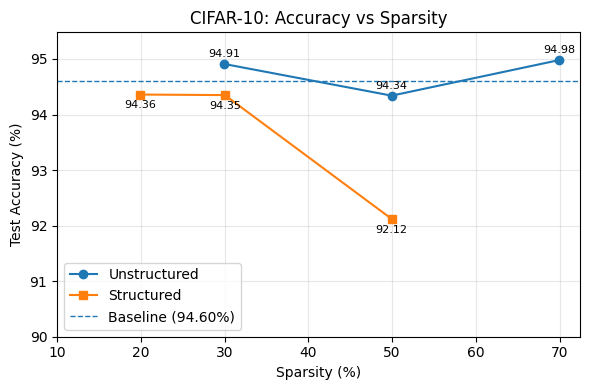

In [ ]:
def plot_cifar_accuracy_zoom(df_unstruct, df_struct, base_acc):
    x_u = (df_unstruct["sparsity"] * 100.0).tolist()
    y_u = (df_unstruct["acc_after"] * 100.0).tolist()

    x_s = (df_struct["sparsity"] * 100.0).tolist()
    y_s = (df_struct["acc_after"] * 100.0).tolist()

    plt.figure(figsize=(6,4))
    plt.plot(x_u, y_u, marker="o", linestyle="-", label="Unstructured")
    plt.plot(x_s, y_s, marker="s", linestyle="-", label="Structured")

    # baseline
    plt.axhline(base_acc*100.0, linestyle="--", linewidth=1,
                label=f"Baseline ({base_acc*100:.2f}%)")

    plt.xlabel("Sparsity (%)")
    plt.ylabel("Test Accuracy (%)")
    plt.title("CIFAR-10: Accuracy vs Sparsity")


    ymin = min(y_u + y_s + [base_acc*100]) - 0.5
    ymax = max(y_u + y_s + [base_acc*100]) + 0.5
    plt.ylim(90, ymax)

    plt.xticks(list(range(10, 80, 10)))
    plt.grid(True, alpha=0.3)


    for x, y in zip(x_u, y_u):
        plt.annotate(f"{y:.2f}", (x, y), textcoords="offset points",
                     xytext=(0,5), ha="center", fontsize=8)
    for x, y in zip(x_s, y_s):
        plt.annotate(f"{y:.2f}", (x, y), textcoords="offset points",
                     xytext=(0,-10), ha="center", fontsize=8)

    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.show()

plot_cifar_accuracy_zoom(df_cifar_unstruct, df_cifar_struct, base_acc)


cifar latency vs sparsity

In [ ]:
base_model = reload_cifar_baseline()
lat_base, mem_base = measure_cifar_runtime(base_model, testloader, num_batches=50)
print("Baseline latency:", lat_base, "ms/image")
print("Baseline memory:", mem_base, "MB")

Baseline latency: 1.0574930746875566 ms/image
Baseline memory: 3568.7373046875 MB


In [ ]:
def plot_cifar_latency(df_unstruct, df_struct):
    plt.figure()
    plt.plot(df_unstruct["sparsity"]*100.0, df_unstruct["latency_ms_per_img"],
             marker="o", label="Unstructured")
    plt.plot(df_struct["sparsity"]*100.0, df_struct["latency_ms_per_img"],
             marker="s", label="Structured")

    plt.xlabel("Sparsity (%)")
    plt.ylabel("Latency (ms / image)")
    plt.title("CIFAR-10: Latency vs Sparsity")
    plt.grid(True)
    plt.legend()
    plt.show()

#plot_cifar_latency(df_cifar_unstruct, df_cifar_struct)


In [ ]:
print("UNSTRUCTURED COLUMNS:", df_cifar_unstruct.columns.tolist())
print("STRUCTURED COLUMNS   :", df_cifar_struct.columns.tolist())


UNSTRUCTURED COLUMNS: ['amount', 'sparsity', 'acc_before', 'acc_after', 'latency_ms_per_img', 'peak_mem_mb']
STRUCTURED COLUMNS   : ['amount', 'sparsity', 'acc_before', 'acc_after', 'latency_ms_per_img', 'peak_mem_mb']


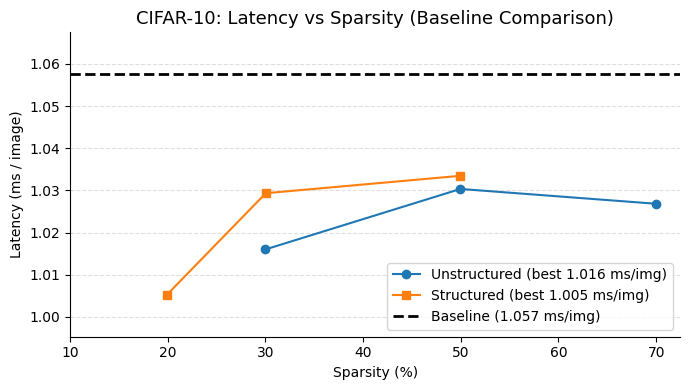

In [ ]:
import matplotlib.pyplot as plt

def plot_cifar_latency_with_baseline(df_unstruct, df_struct, baseline_latency):
    x_u = (df_unstruct["sparsity"] * 100.0).tolist()
    y_u = df_unstruct["latency_ms_per_img"].tolist()

    x_s = (df_struct["sparsity"] * 100.0).tolist()
    y_s = df_struct["latency_ms_per_img"].tolist()

    # Best (lower is better)
    best_u = min(y_u)
    best_s = min(y_s)

    plt.figure(figsize=(7, 4))

    plt.plot(x_u, y_u, marker="o", linestyle="-",
             label=f"Unstructured (best {best_u:.3f} ms/img)")
    plt.plot(x_s, y_s, marker="s", linestyle="-",
             label=f"Structured (best {best_s:.3f} ms/img)")

    plt.axhline(
        baseline_latency,
        color="black",
        linestyle="--",
        linewidth=2,
        label=f"Baseline ({baseline_latency:.3f} ms/img)",
    )

    all_lat = y_u + y_s + [baseline_latency]
    ymin = min(all_lat) - 0.01
    ymax = max(all_lat) + 0.01
    plt.ylim(ymin, ymax)


    plt.xticks(list(range(10, 80, 10)))
    plt.xlabel("Sparsity (%)")
    plt.ylabel("Latency (ms / image)")
    plt.title("CIFAR-10: Latency vs Sparsity (Baseline Comparison)", fontsize=13)

    plt.grid(axis="y", linestyle="--", alpha=0.4)
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.legend()
    plt.tight_layout()
    plt.show()

# call
plot_cifar_latency_with_baseline(df_cifar_unstruct, df_cifar_struct, lat_base)


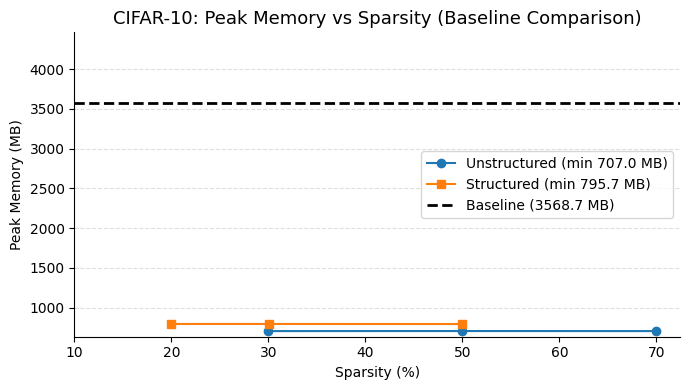

In [ ]:
def plot_cifar_memory_with_baseline(df_unstruct, df_struct, baseline_memory):
    x_u = (df_unstruct["sparsity"] * 100.0).tolist()
    y_u = df_unstruct["peak_mem_mb"].tolist()

    x_s = (df_struct["sparsity"] * 100.0).tolist()
    y_s = df_struct["peak_mem_mb"].tolist()

    # Best (lower is better)
    best_u = min(y_u)
    best_s = min(y_s)

    plt.figure(figsize=(7, 4))

    plt.plot(x_u, y_u, marker="o", linestyle="-",
             label=f"Unstructured (min {best_u:.1f} MB)")
    plt.plot(x_s, y_s, marker="s", linestyle="-",
             label=f"Structured (min {best_s:.1f} MB)")

    plt.axhline(
        baseline_memory,
        color="black",
        linestyle="--",
        linewidth=2,
        label=f"Baseline ({baseline_memory:.1f} MB)",
    )

    pruned_mem = y_u + y_s
    ymin = min(pruned_mem) * 0.9
    ymax = baseline_memory * 1.25
    plt.ylim(ymin, ymax)

    plt.xticks(list(range(10, 80, 10)))
    plt.xlabel("Sparsity (%)")
    plt.ylabel("Peak Memory (MB)")
    plt.title("CIFAR-10: Peak Memory vs Sparsity (Baseline Comparison)", fontsize=13)

    plt.grid(axis="y", linestyle="--", alpha=0.4)
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.legend()
    plt.tight_layout()
    plt.show()

# call
plot_cifar_memory_with_baseline(df_cifar_unstruct, df_cifar_struct, mem_base)


In [ ]:
from IPython.display import display

rows_acc_cifar = []

# Baseline (dense)
rows_acc_cifar.append({
    "Method": "Baseline (Dense)",
    "Sparsity (%)": 0,
    "Acc Before (%)": base_acc * 100.0,
    "Acc After (%)":  base_acc * 100.0,
})

# Unstructured
for _, r in df_cifar_unstruct.iterrows():
    rows_acc_cifar.append({
        "Method": "Unstructured",
        "Sparsity (%)": round(r["sparsity"] * 100.0),
        "Acc Before (%)": r["acc_before"] * 100.0,
        "Acc After (%)":  r["acc_after"]  * 100.0,
    })

# Structured
for _, r in df_cifar_struct.iterrows():
    rows_acc_cifar.append({
        "Method": "Structured",
        "Sparsity (%)": round(r["sparsity"] * 100.0),
        "Acc Before (%)": r["acc_before"] * 100.0,
        "Acc After (%)":  r["acc_after"]  * 100.0,
    })

acc_cifar_df = pd.DataFrame(rows_acc_cifar)
acc_cifar_df["Acc Before (%)"] = acc_cifar_df["Acc Before (%)"].round(2)
acc_cifar_df["Acc After (%)"]  = acc_cifar_df["Acc After (%)"].round(2)

# Normalized accuracy w.r.t. baseline (baseline = 100%)
baseline_acc_pct = base_acc * 100.0
acc_cifar_df["Norm Acc (% of base)"] = (
    acc_cifar_df["Acc After (%)"] / baseline_acc_pct
).round(2)

print("CIFAR-10: Accuracy Before / After Finetuning (with normalized accuracy)")
display(acc_cifar_df)

print("\nMarkdown table:\n")
print(acc_cifar_df.to_markdown(index=False))


CIFAR-10: Accuracy Before / After Finetuning (with normalized accuracy)


,Method,Sparsity (%),Acc Before (%),Acc After (%),Norm Acc (% of base)
0,Baseline (Dense),0,94.60,94.60,1.00
1,Unstructured,30,94.29,94.91,1.00
2,Unstructured,50,91.84,94.34,1.00
3,Unstructured,70,54.29,94.98,1.00
4,Structured,20,12.45,94.36,1.00
5,Structured,30,10.00,94.35,1.00
6,Structured,50,10.00,92.12,0.97



Markdown table:

| Method           |   Sparsity (%) |   Acc Before (%) |   Acc After (%) |   Norm Acc (% of base) |
|:-----------------|---------------:|-----------------:|----------------:|-----------------------:|
| Baseline (Dense) |              0 |            94.6  |           94.6  |                   1    |
| Unstructured     |             30 |            94.29 |           94.91 |                   1    |
| Unstructured     |             50 |            91.84 |           94.34 |                   1    |
| Unstructured     |             70 |            54.29 |           94.98 |                   1    |
| Structured       |             20 |            12.45 |           94.36 |                   1    |
| Structured       |             30 |            10    |           94.35 |                   1    |
| Structured       |             50 |            10    |           92.12 |                   0.97 |


In [ ]:
rows_perf_cifar = []

# Baseline
rows_perf_cifar.append({
    "Method": "Baseline (Dense)",
    "Sparsity (%)": 0,
    "Latency (ms/img)": lat_base,
    "Peak Mem (MB)": mem_base,
})

# Unstructured
for _, r in df_cifar_unstruct.iterrows():
    rows_perf_cifar.append({
        "Method": "Unstructured",
        "Sparsity (%)": round(r["sparsity"] * 100.0),
        "Latency (ms/img)": r["latency_ms_per_img"],
        "Peak Mem (MB)": r["peak_mem_mb"],
    })

# Structured
for _, r in df_cifar_struct.iterrows():
    rows_perf_cifar.append({
        "Method": "Structured",
        "Sparsity (%)": round(r["sparsity"] * 100.0),
        "Latency (ms/img)": r["latency_ms_per_img"],
        "Peak Mem (MB)": r["peak_mem_mb"],
    })

perf_cifar_df = pd.DataFrame(rows_perf_cifar)

# Basic rounding
perf_cifar_df["Latency (ms/img)"] = perf_cifar_df["Latency (ms/img)"].round(3)
perf_cifar_df["Peak Mem (MB)"]    = perf_cifar_df["Peak Mem (MB)"].round(1)

# Speedup vs baseline (×)
perf_cifar_df["Speedup (× vs base)"] = (
    lat_base / perf_cifar_df["Latency (ms/img)"]
).round(3)

# Memory reduction vs baseline (%)
perf_cifar_df["Mem Reduction (%)"] = (
    (1.0 - perf_cifar_df["Peak Mem (MB)"] / mem_base) * 100.0
).round(1)

print("CIFAR-10: Latency and Peak Memory (with speedup and % reduction)")
display(perf_cifar_df)

print("\nMarkdown table:\n")
print(perf_cifar_df.to_markdown(index=False))


CIFAR-10: Latency and Peak Memory (with speedup and % reduction)


,Method,Sparsity (%),Latency (ms/img),Peak Mem (MB),Speedup (× vs base),Mem Reduction (%)
0,Baseline (Dense),0,1.057,3568.7,1.000,0.0
1,Unstructured,30,1.016,707.0,1.041,80.2
2,Unstructured,50,1.030,707.6,1.027,80.2
3,Unstructured,70,1.027,707.0,1.030,80.2
4,Structured,20,1.005,796.5,1.052,77.7
5,Structured,30,1.029,796.7,1.028,77.7
6,Structured,50,1.033,795.7,1.024,77.7



Markdown table:

| Method           |   Sparsity (%) |   Latency (ms/img) |   Peak Mem (MB) |   Speedup (× vs base) |   Mem Reduction (%) |
|:-----------------|---------------:|-------------------:|----------------:|----------------------:|--------------------:|
| Baseline (Dense) |              0 |              1.057 |          3568.7 |                 1     |                 0   |
| Unstructured     |             30 |              1.016 |           707   |                 1.041 |                80.2 |
| Unstructured     |             50 |              1.03  |           707.6 |                 1.027 |                80.2 |
| Unstructured     |             70 |              1.027 |           707   |                 1.03  |                80.2 |
| Structured       |             20 |              1.005 |           796.5 |                 1.052 |                77.7 |
| Structured       |             30 |              1.029 |           796.7 |                 1.028 |                77.7 

Wikitext

In [ ]:

base_valid_ppl = 40.53465488495083
lat_base_lm    = lat_ms_tok
mem_base_lm    = mem_mb_lm


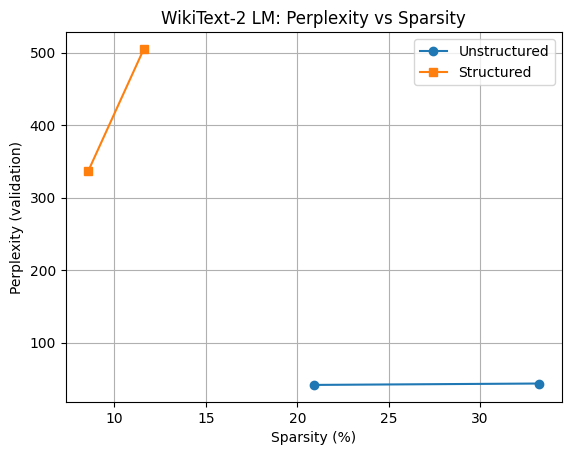

In [ ]:
def plot_lm_perplexity(df_unstruct, df_struct):
    plt.figure()
    plt.plot(df_unstruct["sparsity"]*100.0, df_unstruct["ppl_after"],
             marker="o", label="Unstructured")
    plt.plot(df_struct["sparsity"]*100.0, df_struct["ppl_after"],
             marker="s", label="Structured")

    plt.xlabel("Sparsity (%)")
    plt.ylabel("Perplexity (validation)")
    plt.title("WikiText-2 LM: Perplexity vs Sparsity")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_lm_perplexity(df_lm_unstruct, df_lm_struct)


wikitext latency vs sparsity

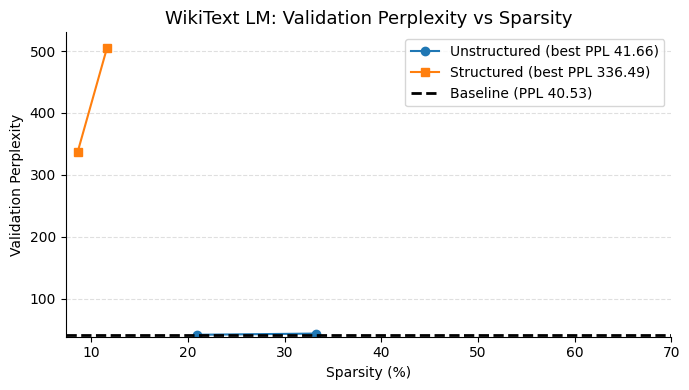

In [ ]:
import matplotlib.pyplot as plt

# Adjust if your column name is different
PPL_COL_AFTER = "ppl_after"   # column in df_lm_unstruct / df_lm_struct

def plot_lm_ppl_with_baseline(df_unstruct, df_struct, baseline_ppl):
    x_u = (df_unstruct["sparsity"] * 100.0).tolist()
    y_u = df_unstruct[PPL_COL_AFTER].tolist()

    x_s = (df_struct["sparsity"] * 100.0).tolist()
    y_s = df_struct[PPL_COL_AFTER].tolist()

    best_u = min(y_u)
    best_s = min(y_s)

    plt.figure(figsize=(7, 4))

    plt.plot(x_u, y_u, marker="o", linestyle="-",
             label=f"Unstructured (best PPL {best_u:.2f})")
    plt.plot(x_s, y_s, marker="s", linestyle="-",
             label=f"Structured (best PPL {best_s:.2f})")

    plt.axhline(
        baseline_ppl,
        color="black",
        linestyle="--",
        linewidth=2,
        label=f"Baseline (PPL {baseline_ppl:.2f})",
    )

    all_ppl = y_u + y_s + [baseline_ppl]
    ymin = min(all_ppl) * 0.95
    ymax = max(all_ppl) * 1.05
    plt.ylim(ymin, ymax)

    plt.xticks(list(range(10, 80, 10)))
    plt.xlabel("Sparsity (%)")
    plt.ylabel("Validation Perplexity")
    plt.title("WikiText LM: Validation Perplexity vs Sparsity", fontsize=13)

    plt.grid(axis="y", linestyle="--", alpha=0.4)
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.legend()
    plt.tight_layout()
    plt.show()

# call
plot_lm_ppl_with_baseline(df_lm_unstruct, df_lm_struct, base_valid_ppl)


In [ ]:
from IPython.display import display
import pandas as pd

PPL_COL_BEFORE = "ppl_before"
PPL_COL_AFTER  = "ppl_after"

rows_ppl_lm = []

rows_ppl_lm.append({
    "Method": "Baseline (Dense)",
    "Sparsity (%)": 0,
    "PPL Before": base_valid_ppl,
    "PPL After":  base_valid_ppl,
})

for _, r in df_lm_unstruct.iterrows():
    rows_ppl_lm.append({
        "Method": "Unstructured",
        "Sparsity (%)": round(r["sparsity"] * 100.0),
        "PPL Before": r[PPL_COL_BEFORE],
        "PPL After":  r[PPL_COL_AFTER],
    })

for _, r in df_lm_struct.iterrows():
    rows_ppl_lm.append({
        "Method": "Structured",
        "Sparsity (%)": round(r["sparsity"] * 100.0),
        "PPL Before": r[PPL_COL_BEFORE],
        "PPL After":  r[PPL_COL_AFTER],
    })

ppl_lm_df = pd.DataFrame(rows_ppl_lm)
ppl_lm_df["PPL Before"] = ppl_lm_df["PPL Before"].round(2)
ppl_lm_df["PPL After"]  = ppl_lm_df["PPL After"].round(2)

ppl_lm_df["Norm PPL (% of base)"] = (
    ppl_lm_df["PPL After"] / base_valid_ppl * 100.0
).round(2)

print("WikiText LM: Validation Perplexity Before / After Pruning")
display(ppl_lm_df)
print("\nMarkdown table:\n")
print(ppl_lm_df.to_markdown(index=False))


WikiText LM: Validation Perplexity Before / After Pruning


,Method,Sparsity (%),PPL Before,PPL After,Norm PPL (% of base)
0,Baseline (Dense),0,4.053000e+01,40.53,99.99
1,Unstructured,21,4.173000e+01,41.66,102.78
2,Unstructured,33,5.095000e+01,43.60,107.56
3,Structured,9,1.353552e+09,336.49,830.13
4,Structured,12,1.849141e+09,505.07,1246.02



Markdown table:

| Method           |   Sparsity (%) |   PPL Before |   PPL After |   Norm PPL (% of base) |
|:-----------------|---------------:|-------------:|------------:|-----------------------:|
| Baseline (Dense) |              0 | 40.53        |       40.53 |                  99.99 |
| Unstructured     |             21 | 41.73        |       41.66 |                 102.78 |
| Unstructured     |             33 | 50.95        |       43.6  |                 107.56 |
| Structured       |              9 |  1.35355e+09 |      336.49 |                 830.13 |
| Structured       |             12 |  1.84914e+09 |      505.07 |                1246.02 |


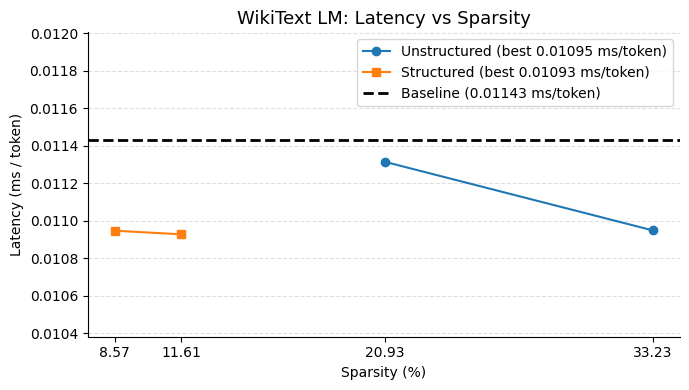

In [ ]:
import matplotlib.pyplot as plt

LAT_COL_LM = "lat_ms_tok"
MEM_COL_LM = "peak_mem_mb"

def plot_lm_latency_with_baseline(df_unstruct, df_struct, baseline_latency):
    x_u = (df_unstruct["sparsity"] * 100.0).tolist()
    y_u = df_unstruct[LAT_COL_LM].tolist()

    x_s = (df_struct["sparsity"] * 100.0).tolist()
    y_s = df_struct[LAT_COL_LM].tolist()

    best_u = min(y_u)
    best_s = min(y_s)

    plt.figure(figsize=(7, 4))
    plt.plot(x_u, y_u, marker="o", linestyle="-",
             label=f"Unstructured (best {best_u:.5f} ms/token)")
    plt.plot(x_s, y_s, marker="s", linestyle="-",
             label=f"Structured (best {best_s:.5f} ms/token)")

    plt.axhline(baseline_latency, color="black", linestyle="--", linewidth=2,
                label=f"Baseline ({baseline_latency:.5f} ms/token)")

    all_lat = y_u + y_s + [baseline_latency]
    ymin = min(all_lat) * 0.95
    ymax = max(all_lat) * 1.05
    plt.ylim(ymin, ymax)

    xticks = sorted(set(x_u + x_s))
    plt.xticks(xticks)

    plt.xlabel("Sparsity (%)")
    plt.ylabel("Latency (ms / token)")
    plt.title("WikiText LM: Latency vs Sparsity", fontsize=13)
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_lm_memory_with_baseline(df_unstruct, df_struct, baseline_memory):
    x_u = (df_unstruct["sparsity"] * 100.0).tolist()
    y_u = df_unstruct[MEM_COL_LM].tolist()

    x_s = (df_struct["sparsity"] * 100.0).tolist()
    y_s = df_struct[MEM_COL_LM].tolist()

    best_u = min(y_u)
    best_s = min(y_s)

    plt.figure(figsize=(7, 4))
    plt.plot(x_u, y_u, marker="o", linestyle="-",
             label=f"Unstructured (min {best_u:.1f} MB)")
    plt.plot(x_s, y_s, marker="s", linestyle="-",
             label=f"Structured (min {best_s:.1f} MB)")

    plt.axhline(baseline_memory, color="black", linestyle="--", linewidth=2,
                label=f"Baseline ({baseline_memory:.1f} MB)")

    pruned_mem = y_u + y_s
    ymin = min(pruned_mem) * 0.9
    ymax = baseline_memory * 1.25
    plt.ylim(ymin, ymax)

    xticks = sorted(set(x_u + x_s))
    plt.xticks(xticks)

    plt.xlabel("Sparsity (%)")
    plt.ylabel("Peak Memory (MB)")
    plt.title("WikiText LM: Peak Memory vs Sparsity", fontsize=13)
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.legend()
    plt.tight_layout()
    plt.show()



plot_lm_latency_with_baseline(df_lm_unstruct, df_lm_struct, lat_base_lm)



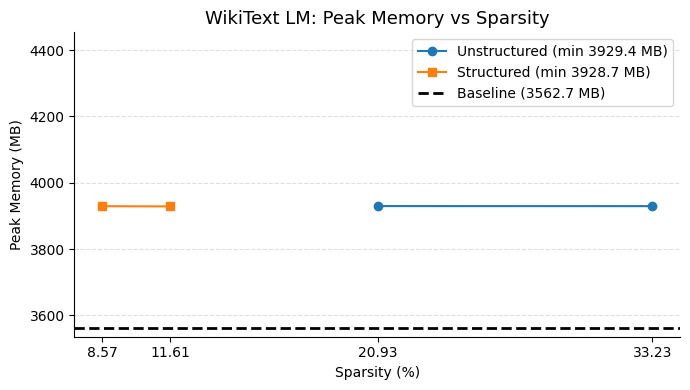

In [ ]:
plot_lm_memory_with_baseline(df_lm_unstruct, df_lm_struct, mem_base_lm)

In [ ]:
from IPython.display import display
import pandas as pd

rows_perf_lm = []

rows_perf_lm.append({
    "Method": "Baseline (Dense)",
    "Sparsity (%)": 0,
    "Latency (ms/token)": lat_base_lm,
    "Peak Mem (MB)": mem_base_lm,
})

for _, r in df_lm_unstruct.iterrows():
    rows_perf_lm.append({
        "Method": "Unstructured",
        "Sparsity (%)": round(r["sparsity"] * 100.0),
        "Latency (ms/token)": r["lat_ms_tok"],
        "Peak Mem (MB)": r["peak_mem_mb"],
    })

for _, r in df_lm_struct.iterrows():
    rows_perf_lm.append({
        "Method": "Structured",
        "Sparsity (%)": round(r["sparsity"] * 100.0),
        "Latency (ms/token)": r["lat_ms_tok"],
        "Peak Mem (MB)": r["peak_mem_mb"],
    })

perf_lm_df = pd.DataFrame(rows_perf_lm)
perf_lm_df["Latency (ms/token)"] = perf_lm_df["Latency (ms/token)"].round(6)
perf_lm_df["Peak Mem (MB)"]      = perf_lm_df["Peak Mem (MB)"].round(1)

perf_lm_df["Speedup (× vs base)"] = (
    lat_base_lm / perf_lm_df["Latency (ms/token)"]
).round(3)

perf_lm_df["Mem Reduction (%)"] = (
    (1.0 - perf_lm_df["Peak Mem (MB)"] / mem_base_lm) * 100.0
).round(1)

print("WikiText LM: Latency and Peak Memory (with speedup & mem reduction)")
display(perf_lm_df)
print("\nMarkdown table:\n")
print(perf_lm_df.to_markdown(index=False))


WikiText LM: Latency and Peak Memory (with speedup & mem reduction)


,Method,Sparsity (%),Latency (ms/token),Peak Mem (MB),Speedup (× vs base),Mem Reduction (%)
0,Baseline (Dense),0,0.011433,3562.7,1.000,0.0
1,Unstructured,21,0.011314,3929.6,1.011,-10.3
2,Unstructured,33,0.010948,3929.4,1.044,-10.3
3,Structured,9,0.010946,3929.3,1.044,-10.3
4,Structured,12,0.010927,3928.7,1.046,-10.3



Markdown table:

| Method           |   Sparsity (%) |   Latency (ms/token) |   Peak Mem (MB) |   Speedup (× vs base) |   Mem Reduction (%) |
|:-----------------|---------------:|---------------------:|----------------:|----------------------:|--------------------:|
| Baseline (Dense) |              0 |             0.011433 |          3562.7 |                 1     |                 0   |
| Unstructured     |             21 |             0.011314 |          3929.6 |                 1.011 |               -10.3 |
| Unstructured     |             33 |             0.010948 |          3929.4 |                 1.044 |               -10.3 |
| Structured       |              9 |             0.010946 |          3929.3 |                 1.044 |               -10.3 |
| Structured       |             12 |             0.010927 |          3928.7 |                 1.046 |               -10.3 |
